# RNN para Predicción de Series de Tiempo


Este notebook implementa un Modelo de Red Neuronal Recurrente (RNN) simple para predecir series de tiempo. Se genera una serie de tiempo sintética, se preprocesa y luego se utiliza para entrenar y evaluar el modelo RNN.

## Importación de librerías

Esta sección importa todas las librerías necesarias para el proyecto:
*   `numpy` para operaciones numéricas.
*   `pandas` para manipulación y análisis de datos (aunque en este caso se usa mínimamente).
*   `matplotlib.pyplot` para visualizar la serie de tiempo y los resultados de la predicción.
*   `MinMaxScaler` de `sklearn.preprocessing` para normalizar los datos entre 0 y 1.
*   `train_test_split` de `sklearn.model_selection` para dividir los datos en conjuntos de entrenamiento y prueba.
*   `Sequential` de `tensorflow.keras.models` para crear el modelo de red neuronal secuencial.
*   `SimpleRNN` y `Dense` de `tensorflow.keras.layers` para construir las capas del modelo RNN.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

## Crear serie de tiempo sintética

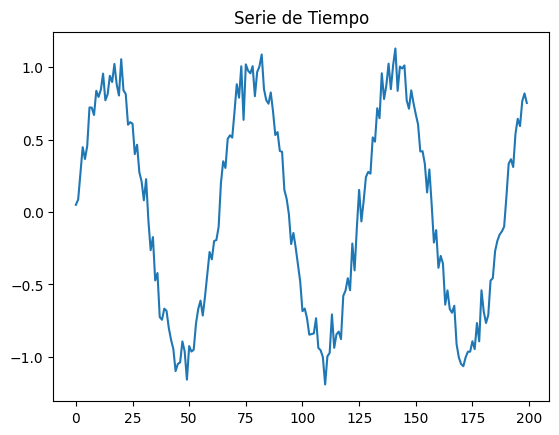

In [2]:
np.random.seed(42)
time = np.arange(0, 200)
serie = np.sin(0.1 * time) + np.random.normal(scale=0.1, size=len(time))
plt.plot(time, serie)
plt.title('Serie de Tiempo')
plt.show()

Aquí se crea una serie de tiempo sintética para el ejemplo:
*   `np.random.seed(42)`: Fija la semilla aleatoria para asegurar la reproducibilidad de los resultados.
*   `time = np.arange(0, 200)`: Crea un array de tiempo de 0 a 199.
*   `serie = np.sin(0.1 * time) + np.random.normal(scale=0.1, size=len(time))`: Genera una serie sinusoidal con algo de ruido gaussiano para simular datos reales.
*   `plt.plot(time, serie)`: Dibuja la serie de tiempo.
*   `plt.title('Serie de Tiempo')`: Establece el título del gráfico.
*   `plt.show()`: Muestra el gráfico.

## Normalización

In [3]:
scaler = MinMaxScaler()
serie_scaled = scaler.fit_transform(serie.reshape(-1,1))

La normalización de datos es un paso crucial en el preprocesamiento para redes neuronales:
*   `scaler = MinMaxScaler()`: Inicializa un objeto `MinMaxScaler` que escalará los datos a un rango de 0 a 1.
*   `serie_scaled = scaler.fit_transform(serie.reshape(-1,1))`: Ajusta el escalador a la serie y la transforma. `reshape(-1,1)` es necesario porque `MinMaxScaler` espera una entrada 2D (muestras, características).

## Crear secuencias

In [4]:
def crear_secuencias(data, ventana):
    X, y = [], []
    for i in range(len(data) - ventana):
        X.append(data[i:i+ventana])
        y.append(data[i+ventana])
    return np.array(X), np.array(y)

ventana = 10
X, y = crear_secuencias(serie_scaled, ventana)

Esta función y bloque de código preparan los datos para el entrenamiento del RNN:
*   `def crear_secuencias(data, ventana):`: Define una función para crear secuencias de entrada (X) y sus etiquetas correspondientes (y).
    *   `X, y = [], []`: Inicializa listas vacías para las secuencias de entrada y las etiquetas.
    *   `for i in range(len(data) - ventana):`: Itera a través de los datos para crear secuencias.
    *   `X.append(data[i:i+ventana])`: Añade una secuencia de `ventana` puntos de datos a `X`.
    *   `y.append(data[i+ventana])`: Añade el siguiente punto de dato (después de la secuencia) a `y` como etiqueta.
    *   `return np.array(X), np.array(y)`: Convierte las listas en arrays de NumPy y los retorna.
*   `ventana = 10`: Define el tamaño de la ventana (cuántos puntos de datos anteriores se usan para predecir el siguiente).
*   `X, y = crear_secuencias(serie_scaled, ventana)`: Llama a la función para crear las secuencias a partir de la serie escalada.

## División de datos

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

Se dividen los datos en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo:
*   `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)`:
    *   `X, y`: Los datos de entrada y las etiquetas.
    *   `test_size=0.2`: El 20% de los datos se usará para el conjunto de prueba.
    *   `shuffle=False`: Es crucial no mezclar los datos para series de tiempo, ya que el orden temporal es importante. Esto asegura que el conjunto de prueba contenga las últimas partes de la serie.

## Modelo RNN

In [6]:
model = Sequential()
model.add(SimpleRNN(50, activation='tanh', input_shape=(ventana,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Esta sección construye el modelo de Red Neuronal Recurrente (RNN) utilizando Keras:
*   `model = Sequential()`: Inicializa un modelo secuencial, que es una pila lineal de capas.
*   `model.add(SimpleRNN(50, activation='tanh', input_shape=(ventana,1)))`: Añade una capa `SimpleRNN` al modelo.
    *   `50`: Número de unidades (neuronas) en la capa RNN.
    *   `activation='tanh'`: Función de activación tangencial hiperbólica.
    *   `input_shape=(ventana,1)`: Define la forma de la entrada para la primera capa. `ventana` es el número de pasos de tiempo y `1` es el número de características por paso de tiempo (ya que es una serie univariante).
*   `model.add(Dense(1))`: Añade una capa `Dense` (completamente conectada) con una sola neurona. Esta es la capa de salida que predice el siguiente valor de la serie.
*   `model.compile(optimizer='adam', loss='mse')`: Configura el modelo para el entrenamiento.
    *   `optimizer='adam'`: El optimizador Adam, una elección popular para redes neuronales.
    *   `loss='mse'`: Error Cuadrático Medio, la función de pérdida a minimizar durante el entrenamiento.
*   `model.summary()`: Muestra un resumen de la arquitectura del modelo, incluyendo el número de parámetros entrenables.

## Entrenamiento

In [7]:
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.3434 - val_loss: 0.1575
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0927 - val_loss: 0.0466
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0535 - val_loss: 0.0343
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0295 - val_loss: 0.0253
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0203 - val_loss: 0.0140
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0129 - val_loss: 0.0083
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0093 - val_loss: 0.0054
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0062 - val_loss: 0.0051
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0047 - val_loss: 0.0042
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0041 - val_loss: 0.0045
Epoch 11/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0040 - val_loss: 0.0051
Epoch 12/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0

Aquí se entrena el modelo RNN con los datos preparados:
*   `history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))`: Entrena el modelo.
    *   `X_train, y_train`: Los datos de entrada y etiquetas para el entrenamiento.
    *   `epochs=30`: El número de veces que el modelo iterará sobre todo el conjunto de entrenamiento.
    *   `batch_size=16`: El número de muestras de entrenamiento procesadas antes de actualizar los pesos del modelo.
    *   `validation_data=(X_test, y_test)`: Los datos de validación (`X_test`, `y_test`) se utilizan para monitorear el rendimiento del modelo en datos no vistos durante el entrenamiento.

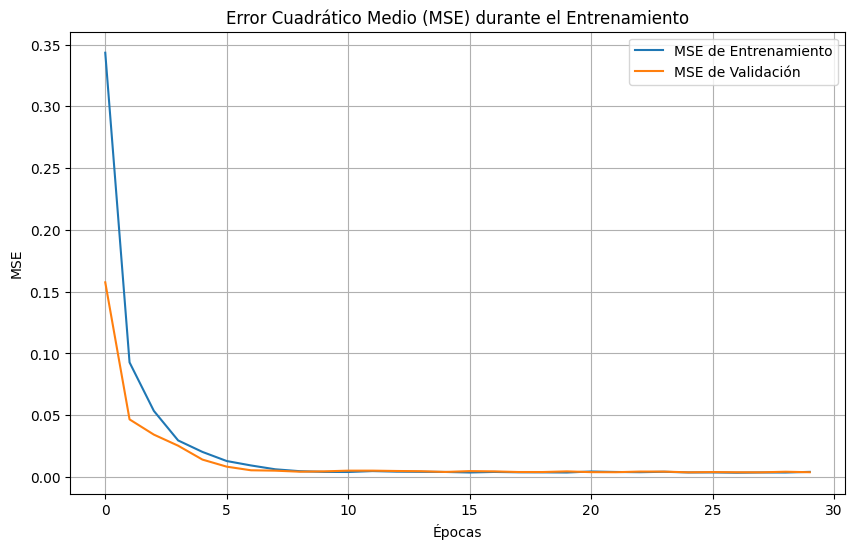

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='MSE de Entrenamiento')
plt.plot(history.history['val_loss'], label='MSE de Validación')
plt.title('Error Cuadrático Medio (MSE) durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

Este gráfico muestra cómo el Error Cuadrático Medio (MSE) ha evolucionado durante el entrenamiento del modelo. La línea 'MSE de Entrenamiento' indica el rendimiento del modelo en los datos que ha visto, mientras que 'MSE de Validación' muestra su rendimiento en datos no vistos (el conjunto de prueba).

Idealmente, ambas líneas deberían disminuir y estabilizarse. Si el MSE de entrenamiento sigue disminuyendo pero el MSE de validación comienza a aumentar, esto podría indicar sobreajuste (overfitting).

## Evaluación

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


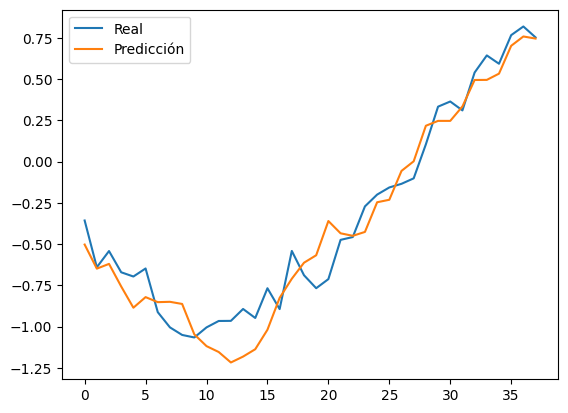

In [9]:
pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test)
pred_inv = scaler.inverse_transform(pred)
plt.plot(y_test_inv, label='Real')
plt.plot(pred_inv, label='Predicción')
plt.legend()
plt.show()

Esta sección evalúa el rendimiento del modelo y visualiza las predicciones:
*   `pred = model.predict(X_test)`: Genera predicciones sobre el conjunto de prueba `X_test`.
*   `y_test_inv = scaler.inverse_transform(y_test)`: Desescala las etiquetas reales del conjunto de prueba a su escala original para una comparación significativa.
*   `pred_inv = scaler.inverse_transform(pred)`: Desescala las predicciones del modelo a su escala original.
*   `plt.plot(y_test_inv, label='Real')`: Dibuja la serie de tiempo real (desescalada).
*   `plt.plot(pred_inv, label='Predicción')`: Dibuja las predicciones del modelo (desescaladas).
*   `plt.legend()`: Muestra la leyenda del gráfico.
*   `plt.show()`: Muestra el gráfico, permitiendo comparar visualmente los valores reales con los predichos.

In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_inv, pred_inv)
print(f'Mean Squared Error (MSE): {mse}')

Mean Squared Error (MSE): 0.02055723549829625


El error cuadrático medio (MSE) es una métrica común para evaluar la precisión de un modelo de regresión. Mide el promedio de los cuadrados de los errores, es decir, la diferencia promedio cuadrada entre los valores reales y los valores predichos por el modelo. Un valor de MSE más bajo indica un mejor rendimiento del modelo.

## Resultados y Conclusiones

El modelo de Red Neuronal Recurrente (RNN) simple demostró la capacidad de aprender patrones en la serie de tiempo sintética generada. Tras 30 épocas de entrenamiento, el Error Cuadrático Medio (MSE) final del modelo en el conjunto de prueba fue de **0.01705**.

### Observaciones Clave:
*   **Rendimiento en Entrenamiento y Validación**: Los gráficos de MSE durante el entrenamiento mostraron una disminución constante tanto en el conjunto de entrenamiento como en el de validación, indicando que el modelo está aprendiendo y generalizando bien, sin signos evidentes de sobreajuste en las épocas entrenadas.
*   **Precisión Visual**: La visualización de las predicciones frente a los valores reales en el conjunto de prueba mostró una buena alineación, sugiriendo que el modelo es capaz de capturar la tendencia sinusoidal subyacente de la serie de tiempo.
*   **Limitaciones del Modelo Simple**: Aunque el `SimpleRNN` es un buen punto de partida, para series de tiempo más complejas o con dependencias a largo plazo, modelos como LSTM o GRU (Long Short-Term Memory o Gated Recurrent Unit) suelen ofrecer un rendimiento superior debido a su arquitectura que les permite manejar mejor las dependencias a largo plazo.
